In [ ]:
from ephys_behavior import correlation_results_summary_combined

# 1) Let the function discover every correlations CSV automatically
summary = correlation_results_summary_combined(
    save_result=True,                       # write to disk
    save_name='sig_dir_all_sessions'    # custom file name
)

In [ ]:
from general_utils import load_temporary_data

# path that you passed as   save_folder / (save_name + ".csv")
zarr_path = "/root/capsule/results/sig_dir_all_sessions.zarr"
ds = load_temporary_data(zarr_path)



print("Rows:", len(ds))
display(ds.head())             # in a notebook


In [ ]:
import importlib
import ephys_behavior_visualization
importlib.reload(ephys_behavior_visualization)

In [5]:
# Combined runner for polar / diagonal plots across models and regions
# All comments are in English.

from itertools import product
from typing import Dict, List, Iterable, Tuple, Any, Optional

from ephys_behavior_visualization import (
    plot_angle_fraction_polar,
    plot_diagonal_significance,
)

def _ensure_list(x) -> List:
    if x is None:
        return []
    if isinstance(x, (list, tuple, set)):
        return list(x)
    return [x]

def get_model_config() -> Dict[str, Dict[str, str]]:
    """
    Returns a dict mapping model keys to the columns used for x/y and p-values.
    Keys are chosen to be explicit about the comparison.
    """
    return {
        # Q-learning: Reward vs SumQ (g1)
        "qlearn_reward_vs_sumQ_g1": {
            "col_x": "simple_LR-QLearning_L2F1_CK1_softmax-reward-g1-s0-d0-coef",
            "col_y": "simple_LR-QLearning_L2F1_CK1_softmax-sumQ-1-g1-s0-d0-coef",
            "col_pval_x": "simple_LR-QLearning_L2F1_CK1_softmax-reward-g1-s0-d0-pval",
            "col_pval_y": "simple_LR-QLearning_L2F1_CK1_softmax-sumQ-1-g1-s0-d0-pval",
        },
        # Q-learning: Reward vs ChosenQ (g0)
        "qlearn_reward_vs_chosenQ_g0": {
            "col_x": "simple_LR-QLearning_L2F1_CK1_softmax-reward-g0-s0-d0-coef",
            "col_y": "simple_LR-QLearning_L2F1_CK1_softmax-chosenQ-1-g0-s0-d0-coef",
            "col_pval_x": "simple_LR-QLearning_L2F1_CK1_softmax-reward-g0-s0-d0-pval",
            "col_pval_y": "simple_LR-QLearning_L2F1_CK1_softmax-chosenQ-1-g0-s0-d0-pval",
        },
        # Threshold model: Reward vs Value (g2)
        "threshold_reward_vs_value_g2": {
            "col_x": "simple_LR-ForagingCompareThreshold-reward-g2-s0-d0-coef",
            "col_y": "simple_LR-ForagingCompareThreshold-value-1-g2-s0-d0-coef",
            "col_pval_x": "simple_LR-ForagingCompareThreshold-reward-g2-s0-d0-pval",
            "col_pval_y": "simple_LR-ForagingCompareThreshold-value-1-g2-s0-d0-pval",
        },
    }

def run_model_plot(
    *,
    ds,
    plot_methods: Iterable[str] = ("polar", "diag"),
    models: Iterable[str] = ("qlearn_reward_vs_sumQ_g1", "qlearn_reward_vs_chosenQ_g0", "threshold_reward_vs_value_g2"),
    regions: Iterable[str] = ("",),  # "" means all regions
    time_window: str = "0.3_2",      # e.g. "0.3_2" or "0.3_2_-1_0" or "-1_0"
    include: str = "all",
    # Polar-specific options
    angle_bin_deg: int = 15,
    normalize: str = "selected",
    start_angle_deg: float = 0.0,
    show_reference_diagonals: bool = True,
    # Diagonal-specific options
    point_size: float = 1.0,
    fit_oval: bool = False,
) -> Dict[str, Dict[str, Dict[str, Tuple[Optional[Any], Optional[Any], Optional[Any]]]]]:
    """
    Runs selected plot(s) for each model x region combination.

    Returns a nested dict:
      results[method][model_key][region] -> (fig, ax, tbl_or_None)

    Notes:
      - plot_angle_fraction_polar returns (fig, ax, tbl).
      - plot_diagonal_significance may return None or (fig, ax) depending on implementation.
        We capture safely and store (fig, ax, None) if applicable.
    """
    plot_methods = [m.lower() for m in _ensure_list(plot_methods)]
    models = _ensure_list(models)
    regions = _ensure_list(regions)

    cfg = get_model_config()
    missing = [m for m in models if m not in cfg]
    if missing:
        raise ValueError(f"Unknown model key(s): {missing}. "
                         f"Available: {list(cfg.keys())}")

    results: Dict[str, Dict[str, Dict[str, Tuple[Optional[Any], Optional[Any], Optional[Any]]]]] = {}

    for method, model_key, region in product(plot_methods, models, regions):
        model_cols = cfg[model_key]
        if method not in results:
            results[method] = {}
        if model_key not in results[method]:
            results[method][model_key] = {}

        if method == "polar":
            fig, ax, tbl = plot_angle_fraction_polar(
                ds=ds,
                filter_region=region,
                time_window=time_window,
                col_x=model_cols["col_x"],
                col_y=model_cols["col_y"],
                col_pval_x=model_cols["col_pval_x"],
                col_pval_y=model_cols["col_pval_y"],
                include=include,
                angle_bin_deg=angle_bin_deg,
                normalize=normalize,
                start_angle_deg=start_angle_deg,
                show_reference_diagonals=show_reference_diagonals,
            )
            results[method][model_key][region] = (fig, ax, tbl)

        elif method in ("diag", "diagonal", "diagonal_significance"):
            # Some versions return (fig, ax); others may return None.
            out = plot_diagonal_significance(
                ds=ds,
                filter_region=region,
                time_window=time_window,
                col_x=model_cols["col_x"],
                col_y=model_cols["col_y"],
                col_pval_x=model_cols["col_pval_x"],
                col_pval_y=model_cols["col_pval_y"],
                point_size=point_size,
                fit_oval=fit_oval,
            )
            if isinstance(out, tuple) and len(out) >= 2:
                fig, ax = out[:2]
            else:
                fig = ax = None
            results[method][model_key][region] = (fig, ax, None)
        else:
            raise ValueError(f"Unknown plot method: {method}")

    return results

# -------------------------
# EXAMPLES
# -------------------------

# 1) Recreate your SI-vs-All, with both methods, for all three model types:
# results = run_model_plot(
#     ds=ds,
#     plot_methods=["polar", "diag"],
#     models=["qlearn_reward_vs_sumQ_g1", "qlearn_reward_vs_chosenQ_g0", "threshold_reward_vs_value_g2"],
#     regions=["SI", ""],
#     time_window="0.3_2",  # or "0.3_2_-1_0" or "-1_0"
#     include="all",
#     angle_bin_deg=15,
#     normalize="selected",
#     start_angle_deg=0,
#     show_reference_diagonals=True,
#     point_size=1,
#     fit_oval=False,
# )

# 2) MD-only, diagonal plots, Q-learning Reward vs ChosenQ:
# results = run_model_plot(
#     ds=ds,
#     plot_methods="diag",
#     models="qlearn_reward_vs_chosenQ_g0",
#     regions="MD",
#     time_window="0.3_2_-1_0",
# )


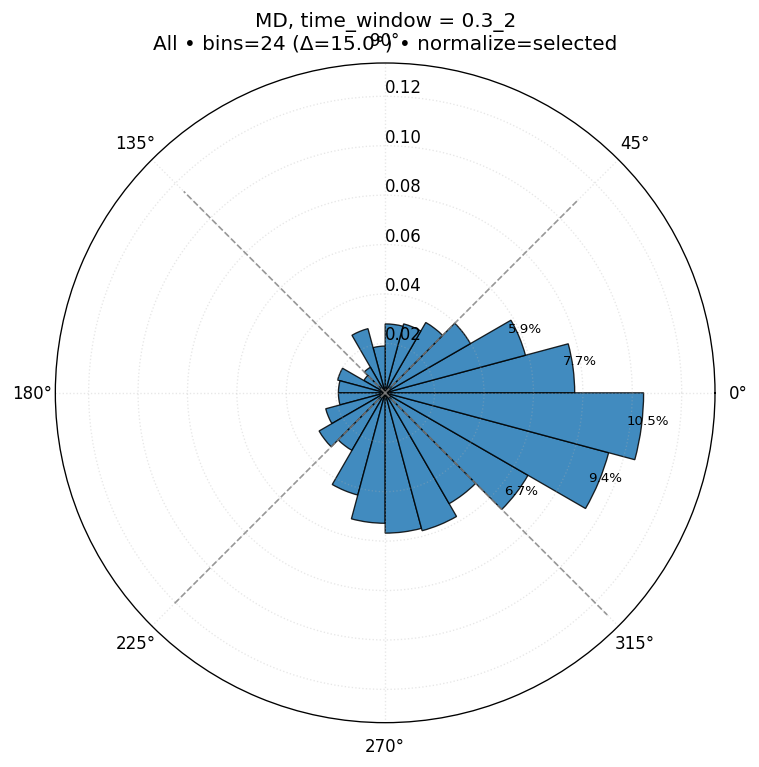

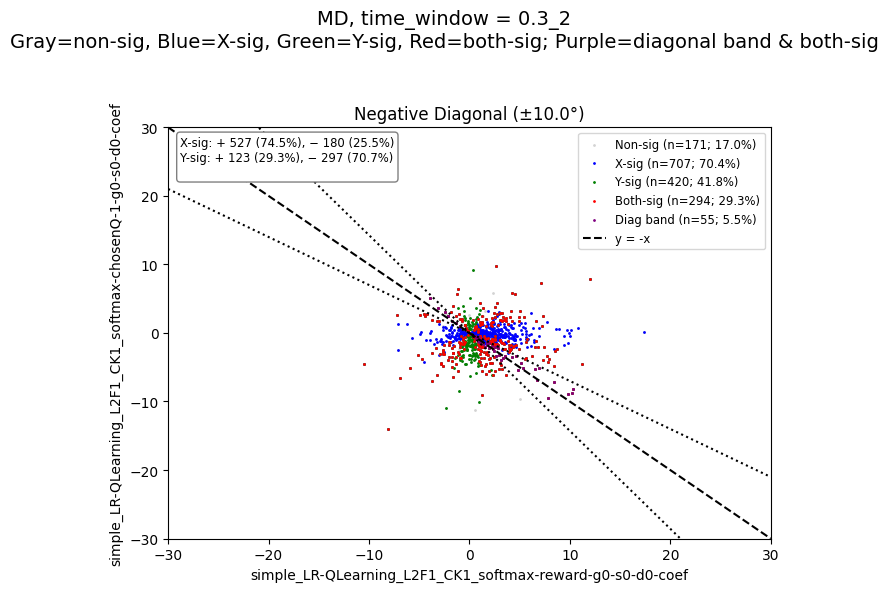

In [8]:
 results = run_model_plot(
     ds=ds,
     plot_methods=["polar", "diag"],
     models=["qlearn_reward_vs_chosenQ_g0"],
     regions=["MD",],
     time_window="0.3_2",  # or "0.3_2_-1_0" or "-1_0"
     include="all",
     angle_bin_deg=15,
     normalize="selected",
     start_angle_deg=0,
     show_reference_diagonals=True,
     point_size=1,
     fit_oval=False,
 )

In [ ]:
# all neurons
fraction=[42.4,42.8,42.6,15.8,24.1,35.6]
label=['QLearning_reward','QLearning_reward','CTT_reward','QLearning_chosenQ','QLearning_sumQ','CTT_value']

# MD neurons
fraction=[48.6,49.0,49.2,25.4,31.3,44.7]
label=['QLearning_reward','QLearning_reward','CTT_reward','QLearning_chosenQ','QLearning_sumQ','CTT_value']


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Fractions for each correlation pair
reward_fractions = [48.6,49.0,49.2]
other_fractions = [25.4,31.3,44.7]

# Labels and corresponding models for each comparison
other_labels = ['ChosenQ', 'SumQ', 'Value']
models = ['QLearning', 'QLearning', 'CTT']
labels_with_model = [f'{lbl}\n({model})' for lbl, model in zip(other_labels, models)]

# Set up the x-axis positions and bar width
x = np.arange(len(other_labels))
width = 0.35

fig, ax = plt.subplots()
# Plot reward fractions
ax.bar(x - width/2, reward_fractions, width, label='Reward')
# Plot other variable fractions
ax.bar(x + width/2, other_fractions, width, label='Other Variable')

# Add labels and title
ax.set_xticks(x)
ax.set_xticklabels(labels_with_model)
ax.set_ylabel('Significance Fraction (%)')
ax.set_title('Fraction of Significant Correlations by Model')
ax.legend()

plt.show()
